# BNS vs BHNS: GRB Population Comparison

Side-by-side comparison of GRB class fractions and formation efficiencies for Binary Neutron Stars (BNS) and Black Hole – Neutron Star (BHNS) mergers.

Uses results from `GRB_BNS.ipynb` (Model A, fiducial) and `GRB_BHNS.ipynb` (Model A, BH spin a=0.5).

Run `GRB_BNS.ipynb` and `GRB_BHNS.ipynb` first to generate the `.npy` export files, or run those notebooks to have the variables in memory.

## 1. Load Saved Efficiency Arrays

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

metallicityGrid = [0.0001, 0.00011, 0.00012, 0.00014, 0.00016, 0.00017,
                   0.00019, 0.00022, 0.00024, 0.00027, 0.0003,  0.00034,
                   0.00037, 0.00042, 0.00047, 0.00052, 0.00058, 0.00065,
                   0.00073, 0.00081, 0.0009,  0.00101, 0.00113, 0.00126,
                   0.0014,  0.00157, 0.00175, 0.00195, 0.00218, 0.00243,
                   0.00272, 0.00303, 0.00339, 0.00378, 0.00422, 0.00471,
                   0.00526, 0.00587, 0.00655, 0.00732, 0.00817, 0.00912,
                   0.01018, 0.01137, 0.01269, 0.01416, 0.01581, 0.01765,
                   0.01971, 0.022,   0.0244,  0.02705, 0.03]

bns  = np.load('/Users/josephrodriguez/research visualization/eff_BNS.npy')
bhns = np.load('/Users/josephrodriguez/research visualization/eff_BHNS.npy')

eff_total_BNS,  eff_short_BNS,  eff_long_BNS   = bns
eff_total_BHNS, eff_long_BHNS_a05              = bhns

print('BNS  — total efficiency range:',
      f'{eff_total_BNS[eff_total_BNS>0].min():.2e} – {eff_total_BNS.max():.2e}')
print('BHNS — total efficiency range:',
      f'{eff_total_BHNS[eff_total_BHNS>0].min():.2e} – {eff_total_BHNS.max():.2e}')

## 2. GRB Class Fractions: BNS vs BHNS

Fraction of all merging systems in each GRB class. BHNS fractions are for assumed BH spin `a = 0.5`.

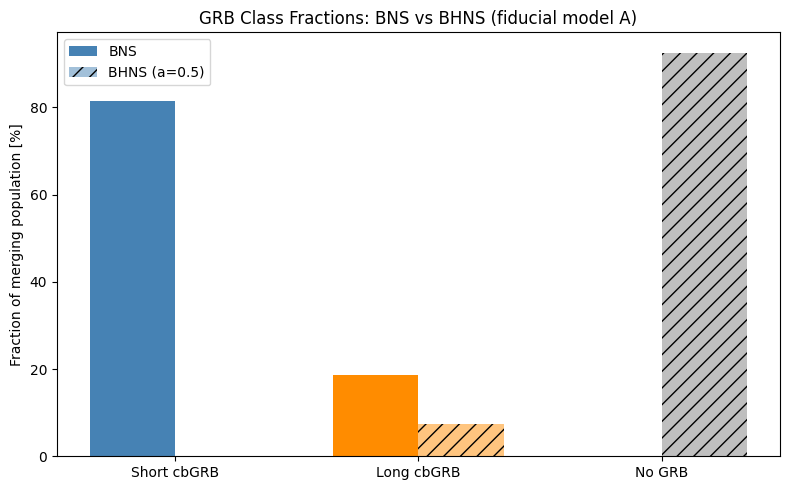

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# BNS from GRB_BNS notebook (hardcode the numbers you already computed)
labels  = ['Short cbGRB', 'Long cbGRB', 'No GRB']
bns_frac  = [81.4, 18.6, 0.0]
bhns_frac = [0.0,  7.4,  92.6]   # a=0.5

x = np.arange(len(labels))
w = 0.35
ax.bar(x - w/2, bns_frac,  w, label='BNS',  color=['steelblue','darkorange','gray'])
ax.bar(x + w/2, bhns_frac, w, label='BHNS (a=0.5)', color=['steelblue','darkorange','gray'], alpha=0.5, hatch='//')

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Fraction of merging population [%]')
ax.set_title('GRB Class Fractions: BNS vs BHNS (fiducial model A)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Formation Efficiency vs Metallicity

BNS (blue) and BHNS (orange) formation efficiency per solar mass of star-forming material, broken down by GRB class.

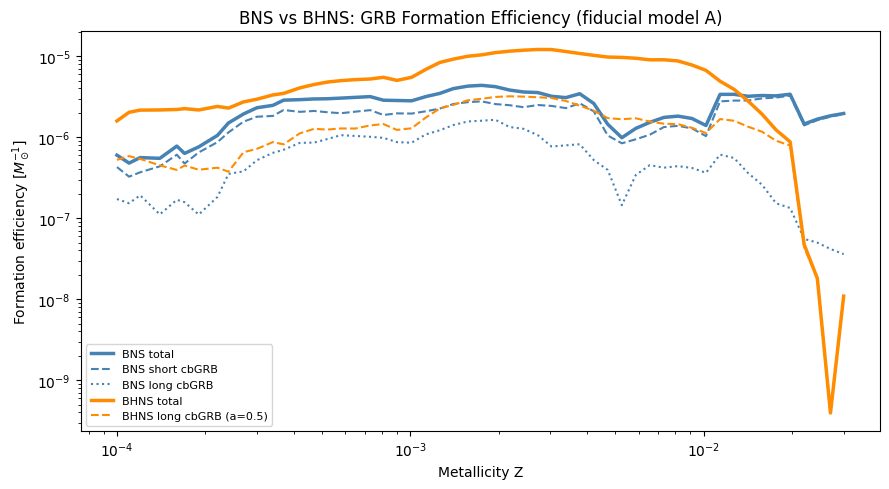

In [ ]:
metallicityGrid = [0.0001, 0.00011, 0.00012, 0.00014, 0.00016, 0.00017,
                   0.00019, 0.00022, 0.00024, 0.00027, 0.0003,  0.00034,
                   0.00037, 0.00042, 0.00047, 0.00052, 0.00058, 0.00065,
                   0.00073, 0.00081, 0.0009,  0.00101, 0.00113, 0.00126,
                   0.0014,  0.00157, 0.00175, 0.00195, 0.00218, 0.00243,
                   0.00272, 0.00303, 0.00339, 0.00378, 0.00422, 0.00471,
                   0.00526, 0.00587, 0.00655, 0.00732, 0.00817, 0.00912,
                   0.01018, 0.01137, 0.01269, 0.01416, 0.01581, 0.01765,
                   0.01971, 0.022,   0.0244,  0.02705, 0.03]

bns  = np.load('/Users/josephrodriguez/research visualization/eff_BNS.npy')
bhns = np.load('/Users/josephrodriguez/research visualization/eff_BHNS.npy')

eff_total_BNS,  eff_short_BNS,  eff_long_BNS   = bns
eff_total_BHNS, eff_long_BHNS_a05              = bhns

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(metallicityGrid, eff_total_BNS,       color='steelblue',  lw=2.5, label='BNS total')
ax.plot(metallicityGrid, eff_short_BNS,        color='steelblue',  lw=1.5, ls='--', label='BNS short cbGRB')
ax.plot(metallicityGrid, eff_long_BNS,         color='steelblue',  lw=1.5, ls=':',  label='BNS long cbGRB')
ax.plot(metallicityGrid, eff_total_BHNS,       color='darkorange', lw=2.5, label='BHNS total')
ax.plot(metallicityGrid, eff_long_BHNS_a05,    color='darkorange', lw=1.5, ls='--', label='BHNS long cbGRB (a=0.5)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Metallicity Z')
ax.set_ylabel(r'Formation efficiency $[M_\odot^{-1}]$')
ax.set_title('BNS vs BHNS: GRB Formation Efficiency (fiducial model A)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()